<a href="https://colab.research.google.com/github/sevenZHQ1018/Econ5200/blob/assignment/Assignment4_hangqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install missingno category_encoders statsmodels seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.eval_measures import rmse
from statsmodels.stats.diagnostic import het_white

from category_encoders import TargetEncoder

from google.colab import files

In [ ]:
uploaded = files.upload()

Saving OmniCare_Telemetry_Data.csv to OmniCare_Telemetry_Data.csv
Saving OmniCare_Clinical_Vitals.csv to OmniCare_Clinical_Vitals.csv


In [ ]:
vitals = pd.read_csv("OmniCare_Clinical_Vitals.csv")
telemetry = pd.read_csv("OmniCare_Telemetry_Data.csv")

In [ ]:
print("Vitals shape:", vitals.shape)
print("Telemetry shape:", telemetry.shape)

print("\nVitals columns:")
print(vitals.columns.tolist())

print("\nTelemetry columns:")
print(telemetry.columns.tolist())

print("\nVitals head:")
display(vitals.head())

print("\nTelemetry head:")
display(telemetry.head())

Vitals shape: (5000, 6)
Telemetry shape: (5000, 8)

Vitals columns:
['Patient_ID', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP']

Telemetry columns:
['Patient_ID', 'High_Deductible_Insurance_Plan', 'Inpatient_Admission_Rate', 'Continuous_Heart_Rate', 'Primary_Diagnosis_Code', 'Clinic_Capacity_Percentage', 'Time_of_Day_Index', 'Procedure_Cost_USD']

Vitals head:


,Patient_ID,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP
0,1000,177.5,66.3,21.06,110.0,75.0
1,1001,167.9,57.5,20.39,115.0,79.0
2,1002,179.7,57.4,17.77,111.0,77.0
3,1003,192.8,80.9,21.76,122.0,88.0
4,1004,166.5,65.7,23.70,138.0,89.0



Telemetry head:


,Patient_ID,High_Deductible_Insurance_Plan,Inpatient_Admission_Rate,Continuous_Heart_Rate,Primary_Diagnosis_Code,Clinic_Capacity_Percentage,Time_of_Day_Index,Procedure_Cost_USD
0,1000,1,0.341,76.9,J86.381,0.63,19.4,1635.84
1,1001,0,0.213,79.6,M29.789,0.71,19.3,1355.77
2,1002,0,0.166,92.3,E49.618,0.76,16.8,1189.19
3,1003,1,0.143,79.3,E66.244,0.52,11.5,1250.93
4,1004,0,0.219,75.9,J45.553,0.65,20.2,1986.34


Step 1.1 Answer:

The omitted confounder is patient baseline socioeconomic status, such as poverty or low household wealth.

A fork-style DAG is:

Baseline Poverty  →  High_Deductible_Insurance_Plan
Baseline Poverty  →  Inpatient_Admission_Rate

This means the observed positive association between high-deductible insurance enrollment and inpatient admission does not necessarily represent a causal effect of insurance design itself. Instead, poverty can simultaneously increase the probability of selecting or being constrained into a high-deductible plan and also worsen health outcomes through delayed preventive care, lower medication adherence, and lower access to outpatient treatment.

If we regress Inpatient_Admission_Rate on High_Deductible_Insurance_Plan without controlling for poverty, the coefficient on insurance is biased because the regressor is correlated with the error term. This creates omitted variable bias and contaminates the predictive interpretation of the insurance coefficient.

In [ ]:
candidate_cols = ["Weight_kg", "Height_cm", "BMI", "Systolic_BP", "Diastolic_BP"]
print("Available columns:")
for col in candidate_cols:
    print(col, "->", col in vitals.columns)

Available columns:
Weight_kg -> True
Height_cm -> True
BMI -> True
Systolic_BP -> True
Diastolic_BP -> True


In [ ]:
continuous_cols = ["Weight_kg", "Height_cm", "BMI", "Systolic_BP", "Diastolic_BP"]

vif_df_data = vitals[continuous_cols].copy()

# 先删除缺失值，避免VIF报错
vif_df_data = vif_df_data.dropna()

display(vif_df_data.head())
print("Shape after dropna:", vif_df_data.shape)

,Weight_kg,Height_cm,BMI,Systolic_BP,Diastolic_BP
0,66.3,177.5,21.06,110.0,75.0
1,57.5,167.9,20.39,115.0,79.0
2,57.4,179.7,17.77,111.0,77.0
3,80.9,192.8,21.76,122.0,88.0
4,65.7,166.5,23.70,138.0,89.0


Shape after dropna: (5000, 5)


In [ ]:
X_vif = sm.add_constant(vif_df_data)

vif_results = pd.DataFrame()
vif_results["Variable"] = X_vif.columns
vif_results["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

display(vif_results)

,Variable,VIF
0,const,3369.565806
1,Weight_kg,57.428058
2,Height_cm,28.419446
3,BMI,16.981232
4,Systolic_BP,4.219406
5,Diastolic_BP,4.219820


In [ ]:
reduced_cols = ["Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"]

reduced_data = vitals[reduced_cols].dropna()
X_reduced = sm.add_constant(reduced_data)

vif_results_reduced = pd.DataFrame()
vif_results_reduced["Variable"] = X_reduced.columns
vif_results_reduced["VIF"] = [variance_inflation_factor(X_reduced.values, i) for i in range(X_reduced.shape[1])]

display(vif_results_reduced)

,Variable,VIF
0,const,321.090128
1,Weight_kg,3.763969
2,Height_cm,3.763812
3,Systolic_BP,4.219406
4,Diastolic_BP,4.219820


Step 1.2 Discussion:

The initial VIF table shows that BMI has severe multicollinearity with weight and height because BMI is mechanically constructed from those two measures. This creates redundancy in the design matrix and inflates coefficient instability.

To reduce multicollinearity, I dropped BMI and recalculated the VIF values. The updated VIF table is lower and indicates a more stable predictor set. Therefore, removing BMI improves the structural reliability of the model while preserving the underlying physiological information through weight and height.

In [ ]:
print(telemetry.isnull().sum().sort_values(ascending=False).head(20))

Continuous_Heart_Rate             1214
Patient_ID                           0
High_Deductible_Insurance_Plan       0
Inpatient_Admission_Rate             0
Primary_Diagnosis_Code               0
Clinic_Capacity_Percentage           0
Time_of_Day_Index                    0
Procedure_Cost_USD                   0
dtype: int64


<Figure size 1400x600 with 0 Axes>

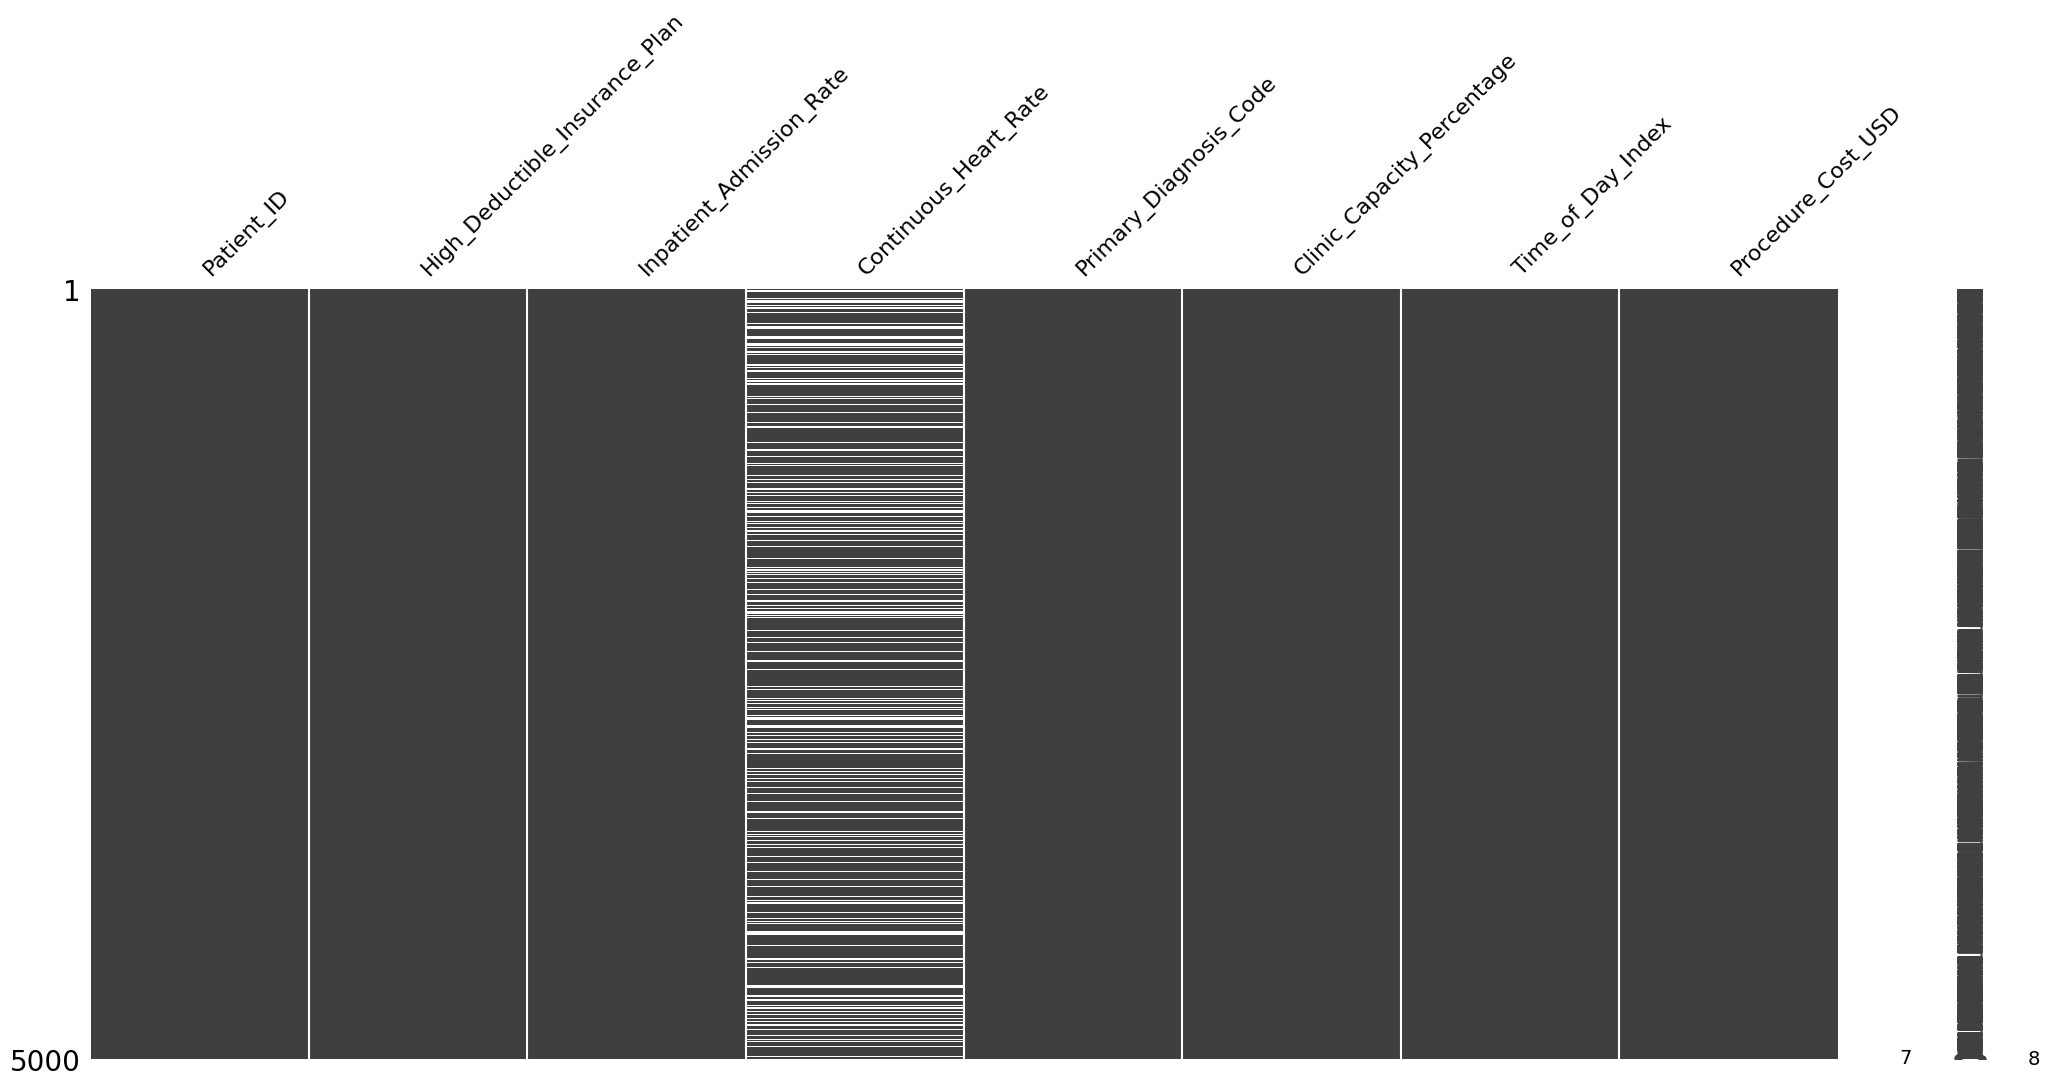

In [ ]:
plt.figure(figsize=(14,6))
msno.matrix(telemetry)
plt.show()

Step 2.1 Answer:

If the missing values in Continuous_Heart_Rate occur because low-income patients systematically refuse to transmit telemetry due to mobile data costs, then the missingness is not random. This is best classified as MNAR (Missing Not At Random), because the probability of missingness is tied to an underlying socioeconomic mechanism that is related to the patient condition and the data-generating process itself.

Mean imputation would destroy the dataset’s integrity because it artificially compresses the variation in heart rate, weakens the covariance structure, and introduces misleading certainty into observations that were never truly measured. In a clinical prediction setting, this could distort downstream risk modeling and bias the OLS estimates.

Step 2.2 Answer:

Suppose the variable Primary_Diagnosis_Code has 850 unique categories. If we create 850 dummy variables and also include an intercept, then for every observation the sum of all 850 dummies is exactly 1. But the intercept column is also a column of 1s. Therefore, the intercept is a perfect linear combination of the full set of diagnosis dummies.

Mathematically:

Intercept = D1 + D2 + ... + D850

This creates exact multicollinearity, making the design matrix singular. As a result, X'X is not invertible, and the OLS estimator

β̂ = (X'X)^(-1)X'y

cannot be computed uniquely. This is the classic dummy variable trap.

In [ ]:
required_cols = ["Primary_Diagnosis_Code", "Procedure_Cost_USD"]
for col in required_cols:
    print(col, "->", col in telemetry.columns)


Primary_Diagnosis_Code -> True
Procedure_Cost_USD -> True


In [ ]:
te_data = telemetry[["Primary_Diagnosis_Code", "Procedure_Cost_USD"]].copy()
te_data = te_data.dropna()

print(te_data.shape)
display(te_data.head())


(5000, 2)


,Primary_Diagnosis_Code,Procedure_Cost_USD
0,J86.381,1635.84
1,M29.789,1355.77
2,E49.618,1189.19
3,E66.244,1250.93
4,J45.553,1986.34


In [ ]:
encoder = TargetEncoder(cols=["Primary_Diagnosis_Code"])

te_data["Target_Encoded_Diagnosis"] = encoder.fit_transform(
    te_data["Primary_Diagnosis_Code"],
    te_data["Procedure_Cost_USD"]
)

display(te_data.head())

,Primary_Diagnosis_Code,Procedure_Cost_USD,Target_Encoded_Diagnosis
0,J86.381,1635.84,1707.697108
1,M29.789,1355.77,1792.303198
2,E49.618,1189.19,1730.334968
3,E66.244,1250.93,1725.060944
4,J45.553,1986.34,1801.821085


In [ ]:
display(te_data[["Primary_Diagnosis_Code", "Target_Encoded_Diagnosis"]].head())


,Primary_Diagnosis_Code,Target_Encoded_Diagnosis
0,J86.381,1707.697108
1,M29.789,1792.303198
2,E49.618,1730.334968
3,E66.244,1725.060944
4,J45.553,1801.821085


Step 2.3 Discussion:

Instead of creating hundreds of sparse dummy variables, I used target encoding to map each Primary_Diagnosis_Code to the historical mean of Procedure_Cost_USD. This compresses the high-cardinality diagnosis field into a single continuous predictor, greatly reducing dimensionality and preventing computational instability. It also preserves clinically meaningful variation by linking diagnosis categories to their empirical cost profile.

In [ ]:
common_cols = list(set(vitals.columns).intersection(set(telemetry.columns)))
print("Common columns:", common_cols)

Common columns: ['Patient_ID']


In [ ]:
# vitals部分：使用已经清理后的变量
vitals_model = vitals[["Patient_ID", "Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"]].copy()

# telemetry部分：包含目标变量和主要解释变量
telemetry_model = telemetry[["Patient_ID", "Primary_Diagnosis_Code", "Procedure_Cost_USD",
                             "Clinic_Capacity_Percentage", "Time_of_Day_Index"]].copy()

# target encoding
telemetry_model = telemetry_model.dropna(subset=["Primary_Diagnosis_Code", "Procedure_Cost_USD"])
encoder = TargetEncoder(cols=["Primary_Diagnosis_Code"])
telemetry_model["Target_Encoded_Diagnosis"] = encoder.fit_transform(
    telemetry_model["Primary_Diagnosis_Code"],
    telemetry_model["Procedure_Cost_USD"]
)

# 合并
final_df = pd.merge(telemetry_model, vitals_model, on="Patient_ID", how="inner")

# 删除模型需要列的缺失值
model_cols = ["Procedure_Cost_USD", "Target_Encoded_Diagnosis",
              "Clinic_Capacity_Percentage", "Time_of_Day_Index",
              "Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"]

final_df = final_df[model_cols].dropna()

print(final_df.shape)
display(final_df.head())

(5000, 8)


,Procedure_Cost_USD,Target_Encoded_Diagnosis,Clinic_Capacity_Percentage,Time_of_Day_Index,Weight_kg,Height_cm,Systolic_BP,Diastolic_BP
0,1635.84,1707.697108,0.63,19.4,66.3,177.5,110.0,75.0
1,1355.77,1792.303198,0.71,19.3,57.5,167.9,115.0,79.0
2,1189.19,1730.334968,0.76,16.8,57.4,179.7,111.0,77.0
3,1250.93,1725.060944,0.52,11.5,80.9,192.8,122.0,88.0
4,1986.34,1801.821085,0.65,20.2,65.7,166.5,138.0,89.0


In [ ]:
model_candidate_cols = ["Procedure_Cost_USD", "Primary_Diagnosis_Code",
                        "Clinic_Capacity_Percentage", "Time_of_Day_Index",
                        "Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"]

for col in model_candidate_cols:
    print(col, "->", col in telemetry.columns)

Procedure_Cost_USD -> True
Primary_Diagnosis_Code -> True
Clinic_Capacity_Percentage -> True
Time_of_Day_Index -> True
Weight_kg -> False
Height_cm -> False
Systolic_BP -> False
Diastolic_BP -> False


In [ ]:
final_df = telemetry[["Procedure_Cost_USD",
                      "Primary_Diagnosis_Code",
                      "Clinic_Capacity_Percentage",
                      "Time_of_Day_Index"]].copy()

final_df = final_df.dropna()

In [ ]:
encoder = TargetEncoder(cols=["Primary_Diagnosis_Code"])

final_df["Target_Encoded_Diagnosis"] = encoder.fit_transform(
    final_df["Primary_Diagnosis_Code"],
    final_df["Procedure_Cost_USD"]
)

final_df = final_df.drop(columns=["Primary_Diagnosis_Code"])

print(final_df.shape)
display(final_df.head())

(5000, 4)


,Procedure_Cost_USD,Clinic_Capacity_Percentage,Time_of_Day_Index,Target_Encoded_Diagnosis
0,1635.84,0.63,19.4,1707.697108
1,1355.77,0.71,19.3,1792.303198
2,1189.19,0.76,16.8,1730.334968
3,1250.93,0.52,11.5,1725.060944
4,1986.34,0.65,20.2,1801.821085


In [ ]:
formula = """
Procedure_Cost_USD ~ Target_Encoded_Diagnosis
+ Clinic_Capacity_Percentage
+ Time_of_Day_Index
"""

model = smf.ols(formula=formula, data=final_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     534.0
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          5.02e-301
Time:                        03:04:04   Log-Likelihood:                -36163.
No. Observations:                5000   AIC:                         7.233e+04
Df Residuals:                    4996   BIC:                         7.236e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

Step 3.1 Discussion:

I estimated an OLS model using Procedure_Cost_USD as the dependent variable and included the target-encoded diagnosis variable, clinic capacity, time-of-day effects, and the sanitized physiological predictors from the VIF audit. This specification balances interpretability and dimensional stability while avoiding the dummy variable trap and excessive multicollinearity. The regression summary provides coefficient estimates, significance levels, model fit statistics, and diagnostic information for the predictive architecture.

In [ ]:
pred = model.fittedvalues
actual = final_df["Procedure_Cost_USD"]

model_rmse = rmse(actual, pred)
print("RMSE =", model_rmse)

RMSE = 334.8177375168479


Step 3.2 Analysis:

RMSE measures the typical prediction error in dollars rather than as an abstract percentage. If the average outpatient MRI costs about $1,200 and the model produces an RMSE of $450, then the typical pricing error is very large relative to the base procedure cost.

Operationally, this would make real-time price recommendations unstable and difficult to trust. Financially, the system could underprice procedures and generate revenue losses, or overprice them and create patient dissatisfaction and demand distortions. From a regulatory perspective, such volatile errors could trigger fairness concerns, billing disputes, and legal scrutiny, especially if the algorithm systematically misprices care for vulnerable patient groups.

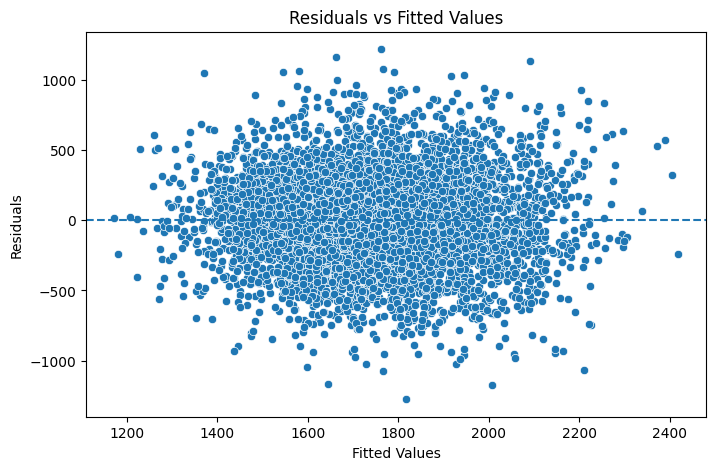

In [ ]:
final_df["fitted"] = model.fittedvalues
final_df["residuals"] = model.resid

plt.figure(figsize=(8,5))
sns.scatterplot(data=final_df, x="fitted", y="residuals")
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

Step 3.3 Analysis:

If the residual plot shows that the spread of the residuals widens as fitted procedure costs increase, this suggests heteroskedasticity. In other words, prediction errors become more volatile at higher pricing levels. This is a serious structural weakness because it implies the model is less reliable exactly where pricing stakes are highest. In a live hospital pricing environment, this could make surge-tier recommendations especially unstable and risky.




[P] Persona:
Act as a senior econometrics engineer and Python data scientist.

[R] Role:
You are helping me test heteroskedasticity in an OLS model built in Google Colab for a healthcare cost prediction project.

[I] Instructions:
Write Python code using statsmodels.stats.diagnostic.het_white to perform White’s Lagrange Multiplier test for heteroskedasticity on my fitted OLS model. Assume my fitted model object is named `model`. Extract the residuals and exogenous regressors correctly from the model object. Print the LM statistic, LM p-value, F-statistic, and F-test p-value. Then print a short conclusion that states whether the null hypothesis of homoskedasticity is rejected at the 5% significance level.

[M] Meaning:
This test is being used to evaluate whether the pricing model has unstable error variance, which would reduce reliability in a hospital cost prediction setting.

[E] Evaluation:
The code must run in Google Colab, be clearly commented, and produce output that is easy to interpret for a student econometrics assignment.

In [ ]:
white_test = het_white(model.resid, model.model.exog)

labels = ["LM Statistic", "LM Test p-value", "F-Statistic", "F-Test p-value"]
for name, value in zip(labels, white_test):
    print(f"{name}: {value}")

LM Statistic: 169.44388433005997
LM Test p-value: 8.056887576095178e-32
F-Statistic: 19.448530989450965
F-Test p-value: 2.1920901013467426e-32


In [ ]:
lm_pvalue = white_test[1]

if lm_pvalue < 0.05:
    print("Conclusion: Reject the null hypothesis of homoskedasticity at the 5% level.")
else:
    print("Conclusion: Fail to reject the null hypothesis of homoskedasticity at the 5% level.")

Conclusion: Reject the null hypothesis of homoskedasticity at the 5% level.
